<a href="https://colab.research.google.com/github/Kul200528/EDAV-PROJECT/blob/main/160124737014.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Problem Statement**:Analyze hospital infrastructure, beds and services distribution across states.
#**Name**:Kulsum Abid
#**Project Id**:CBIT/IT-1/EDAV/2025/CEP-23
#**Roll No**:160124737014
#**Data Set Link**:https://drive.google.com/drive/u/0/folders/1lK7n58ow4o4KECWqyJQbZ_nO-NCxplmB
#**Problem Overview**:
Efficient management and analysis of hospital data are essential for improving healthcare infrastructure and resource allocation. Hospitals often vary in capacity, type, and available facilities across different regions and states. However, the data collected is usually large, inconsistent, and contains missing information, making it difficult to extract meaningful insights directly.

This project focuses on analyzing hospital datasets to identify trends in hospital capacities, available facilities, and geographical distribution. By performing operations such as data grouping, filtering, imputation of missing values, and visualization, we aim to gain a better understanding of:

Total bed capacities across hospitals

Distribution of hospitals by type, region, and category

Handling missing facility data for accurate reporting

Comparing hospital infrastructure across states

Visualizing hospital performance using graphical reports

Through this analysis, policymakers and healthcare administrators can make informed decisions to improve resource planning, facility management, and patient care services.

#**loading and importing necessary library**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("Hospital.csv")

print("Original Dataset:")
print(df)

Original Dataset:
                 Hospital       Type Region Category        State  Beds  \
0       CityCare Hospital    General  North        A      Gujarat   150   
1     Metro Health Center   Surgical  South        B   Tamil Nadu   300   
2         Sunrise Medical    General   East        A  West Bengal   120   
3           Valley Clinic  Specialty   West        C  Maharashtra    80   
4   Green Valley Hospital    General  North        B      Haryana   210   
..                    ...        ...    ...      ...          ...   ...   
72          Global Health   Surgical  North        A        Delhi   270   
73         Horizon Clinic    General  South        C    Karnataka    90   
74     Silverline Medical  Specialty   East        B        Bihar   120   
75          Rivera Center   Surgical   West        C    Rajasthan   195   
76       Harmony Hospital    General  North        B      Haryana     1   

   Facilities_1 Facilities_2 Facilities_3  
0           Yes           No         

#**Q1: Calculate total beds by hospital (BL-3)**

In [ ]:
total_beds = df.groupby('Hospital')['Beds'].sum().reset_index()
print("Q1️⃣ Total Beds by Hospital:")
print(total_beds)
print("\n---------------------------------\n")

Q1️⃣ Total Beds by Hospital:
             Hospital  Beds
0          Ace Clinic   310
1     Advanced Health   167
2     Allied Medicare   127
3        Apex Medical   203
4       Aurora Health   200
..                ...   ...
72       Unity Clinic   184
73      Valley Clinic    80
74    Wellcare Center   225
75  Wellness Hospital   157
76    Zenith Hospital   156

[77 rows x 2 columns]

---------------------------------



#**Q2: Filter hospitals by type and region (BL-3)**

In [ ]:
filtered_hospitals = df[(df['Type'] == 'Surgical') & (df['Region'] == 'South')]
print("Q2️⃣ Surgical Hospitals in South Region:")
print(filtered_hospitals)

#**Q3: Impute missing facilities data (BL-4)**

In [ ]:
df[['Facilities_1', 'Facilities_2', 'Facilities_3']] = df[['Facilities_1', 'Facilities_2', 'Facilities_3']].fillna('Not Available')
print("Q3️⃣ After Imputing Missing Facility Data:")
print(df[['Hospital', 'Facilities_1', 'Facilities_2', 'Facilities_3']])
print("\n---------------------------------\n")


Q3️⃣ After Imputing Missing Facility Data:
                 Hospital   Facilities_1   Facilities_2   Facilities_3
0       CityCare Hospital            Yes             No            Yes
1     Metro Health Center             No            Yes  Not Available
2         Sunrise Medical            Yes            Yes             No
3           Valley Clinic             No             No            Yes
4   Green Valley Hospital            Yes  Not Available             No
..                    ...            ...            ...            ...
72          Global Health             No            Yes             No
73         Horizon Clinic            Yes             No            Yes
74     Silverline Medical             No             No            Yes
75          Rivera Center            Yes             No             No
76       Harmony Hospital  Not Available  Not Available  Not Available

[77 rows x 4 columns]

---------------------------------



#**Q4: Group hospitals by category and state (BL-4)**

In [ ]:
grouped_data = df.groupby(['Category', 'State']).size().reset_index(name='Hospital_Count')
print("Q4️⃣ Hospitals Grouped by Category and State:")
print(grouped_data)
print("\n---------------------------------\n")

Q4️⃣ Hospitals Grouped by Category and State:
   Category             State  Hospital_Count
0         A             Bihar               1
1         A             Delhi               2
2         A           Gujarat               3
3         A         Jharkhand               1
4         A       Maharashtra               4
5         A         Rajasthan               1
6         A        Tamil Nadu               1
7         A       Uttarakhand               1
8         A       West Bengal               2
9         B    Andhra Pradesh               1
10        B             Bihar               3
11        B             Delhi               2
12        B           Gujarat               2
13        B           Haryana               4
14        B         Jharkhand               3
15        B         Karnataka               4
16        B            Kerala               1
17        B       Maharashtra               1
18        B         Rajasthan               2
19        B        Tamil Nadu     

#**Q5: Visual Reports on Hospital Capacity (BL-5)**

/tmp/ipython-input-367925169.py:9: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


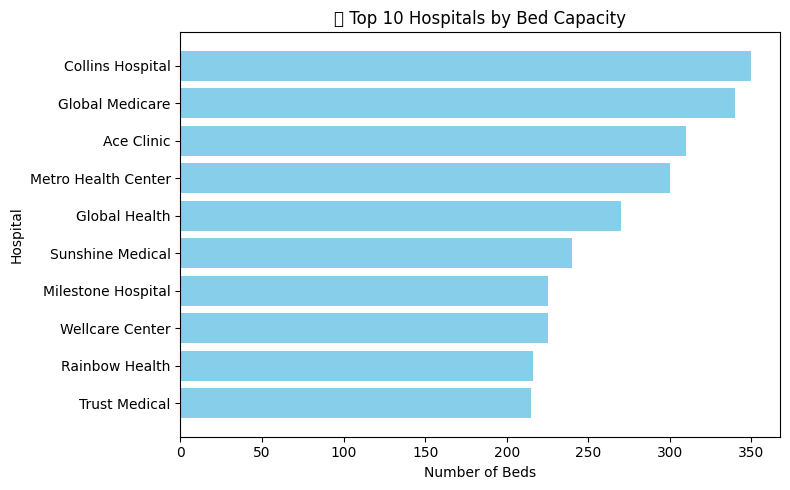

/tmp/ipython-input-367925169.py:20: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


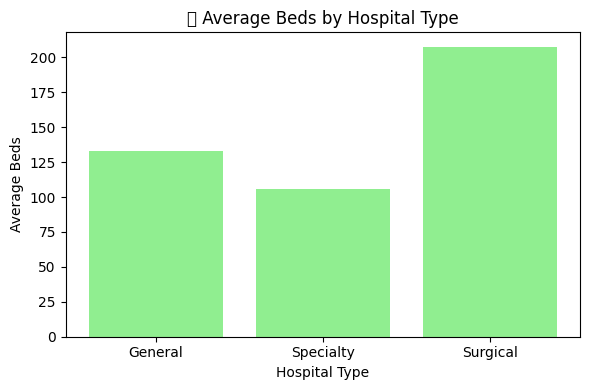

In [ ]:
top_10_beds = df.sort_values(by='Beds', ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(top_10_beds['Hospital'], top_10_beds['Beds'], color='skyblue')
plt.title("🏥 Top 10 Hospitals by Bed Capacity")
plt.xlabel("Number of Beds")
plt.ylabel("Hospital")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 🔸 Visual 2: Average Beds by Hospital Type
avg_beds = df.groupby('Type')['Beds'].mean().reset_index()

plt.figure(figsize=(6,4))
plt.bar(avg_beds['Type'], avg_beds['Beds'], color='lightgreen')
plt.title("📊 Average Beds by Hospital Type")
plt.xlabel("Hospital Type")
plt.ylabel("Average Beds")
plt.tight_layout()
plt.show()